In [1]:
import os, glob

import cytoflow as flow
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from flow_analysis_tools import flow_violin
from flow_analysis_tools.color_palettes import *

from rclone_tools import NodeExperimentsDirectory

## Notebook and Experiment Setup

In [2]:
DRIVE_RELPATH = "ARS_Working/Experiments/LX2-Cas12a-Col1a1-Enhancers/260910_c12c1a1R2_Promoter_Guide_Test/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check"
DATA_DIR = "/data_gilbert3/asathler/hsiung-box"
PROXY = "http://169.230.134.132:3128"

In [3]:
Experiment = NodeExperimentsDirectory(
    drive="hsiung", proxy=PROXY, output_dirname="out",
    source_relpath=DRIVE_RELPATH, node_mountpath=DATA_DIR,
)

In [4]:
Experiment.stage()

In [5]:
%matplotlib widget
matplotlib.rc('figure', dpi = 160)
plt.style.use('ggplot')

In [6]:
FCS_FILES = sorted(glob.glob(os.path.join(Experiment.dest_dirpath, "*.fcs")))
YLIMITS = (0, 7)
CHANNELS = {
    "VL1-A": ["Construct", "mTagBFP2"],
    "BL1-A": ["Guide", "eGFP"],
    "RL1-A": ["Empty", "None"],
    "YL1-A": ["Empty", "None"]
}
ALL_NEG_CONSTRUCT = "HEK"
GATE_INFO = {}
print('\n'.join([f"'{x}'" for x in FCS_FILES]))
if isinstance(Experiment, NodeExperimentsDirectory):
    for x in FCS_FILES: Experiment.logger.info(x)

'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260827_pCH45-pARS002_HEKFixed_Transfection_Check_HEK_HEK.fcs'
'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(1)_gCH75.fcs'
'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(2)_gCH139.fcs'
'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(3)_gCH140.fcs'
'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(4)_gARS006.fcs'
'/data_gilbert3/asathler/hsiung-box/260914_c12a1a1R2_HEK_Fixed_Guide_GFP_Check/260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group_gCH74.fcs'


## Import Setup
Expects file names to have paired identity.

Each construct (e.g. LX2, Cas9, Cas12, pARS001, pARS002) should have 1 or 2 corresponding "guides" (or downstream conditions) assigned to them. So:
- **_LX2_**: Stained & Unstained
- **_Cas9_**: sgNT and sgTargeting
- ...

In [7]:
NAME_N_UNDERSCORE = 1
def get_sample_name(name):
    if "." in name: name = os.path.splitext(name)[0]
    return name.split("_")[-NAME_N_UNDERSCORE]

In [8]:
FCS_NAMES = [os.path.basename(filename) for filename in FCS_FILES]
SAMPLE_NAMES = [get_sample_name(name) for name in FCS_NAMES]
max_fcs_len = max([len(x) for x in FCS_NAMES]) + 5
for fcs, sample_name in zip(FCS_NAMES, SAMPLE_NAMES):
    print_txt = f"{fcs + ''.join([' '] * (max_fcs_len - len(fcs)))}{str(sample_name):<30}"
    print(print_txt)
    if isinstance(Experiment, NodeExperimentsDirectory):
        Experiment.logger.info(print_txt)

import_op = flow.ImportOp(
    conditions = {
        "Construct": "category",
    },
    tubes = [
        flow.Tube(file=fcs_file, conditions={
            "Construct": get_sample_name(fcs_file),
    }) for fcs_file in FCS_FILES],
    # channels = channel_names
)

try:
    ex = import_op.apply()
except ValueError as e:
    error_text = str(e)
    if error_text == "Categorical categories cannot be null":
        raise Exception(
            "Functions 'get_construct_name' or 'get_guide_type' likely are turning None or NoneType." + \
            "\n\t   This is typically because a construct or guide name case isn't properly handled."
        )
    else:
        raise e

260827_pCH45-pARS002_HEKFixed_Transfection_Check_HEK_HEK.fcs      HEK                           
260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(1)_gCH75.fcs       gCH75                         
260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(2)_gCH139.fcs      gCH139                        
260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(3)_gCH140.fcs      gCH140                        
260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group(4)_gARS006.fcs     gARS006                       
260914_c12a1a1_HEK_Fixed_Guide_GFP_Check_Group_gCH74.fcs          gCH74                         


## Select Cells

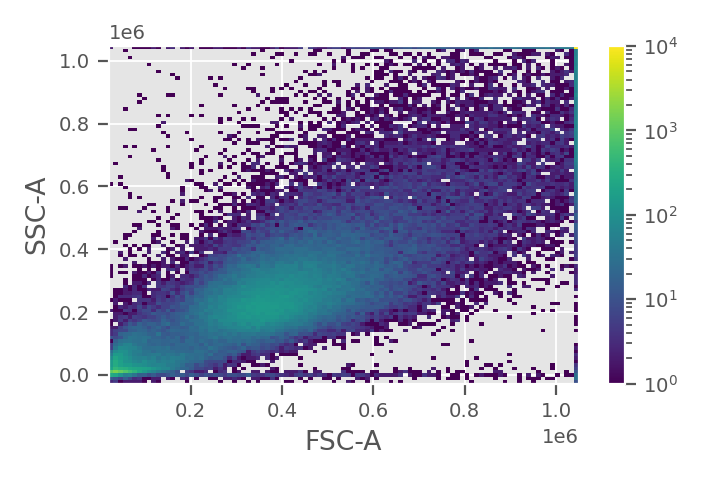

In [9]:
single_gate = flow.PolygonOp(
    name="Single_Cell",
    xchannel="FSC-A",
    ychannel="SSC-A"
)

single_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True
).plot(ex, gridsize = 100)

In [10]:
if isinstance(Experiment, NodeExperimentsDirectory):
    plt.savefig(Experiment.output_dirpath / f"single_cell_gate.png")

In [11]:
GATE_INFO["single_cell_vertices"] = np.asarray(single_gate.vertices)
ex = single_gate.apply(ex)
plt.close()

## Gating

### Gating Template
Use the template below for help with gating

##### Quad Gate
    quad_gate = flow.QuadOp(
        name="",
        xchannel="",
        ychannel="",
    )

##### Single gate
    single_gate = flow.PolygonOp(
        name="",
        xchannel="",
        ychannel="",
        yscale="logicle"
    )

##### Drawing / Applying Gate
    ___gate = flow.PolygonOp(name="") # placeholder variable
    ___gate.default_view(
        density = True,
        huescale = "log",
        interactive = True,
        subset = "Single_Cell == True"
    ) #.plot(ex_single, gridsize=100)
    ex_single_gated = ___gate.apply(ex_single)
    plt.close()


In [12]:
from matplotlib_tools import StepViewer

SyntaxError: invalid syntax (656114101.py, line 1)

CytoflowOpError: ('name', 'Name can only contain letters, numbers and underscores.')

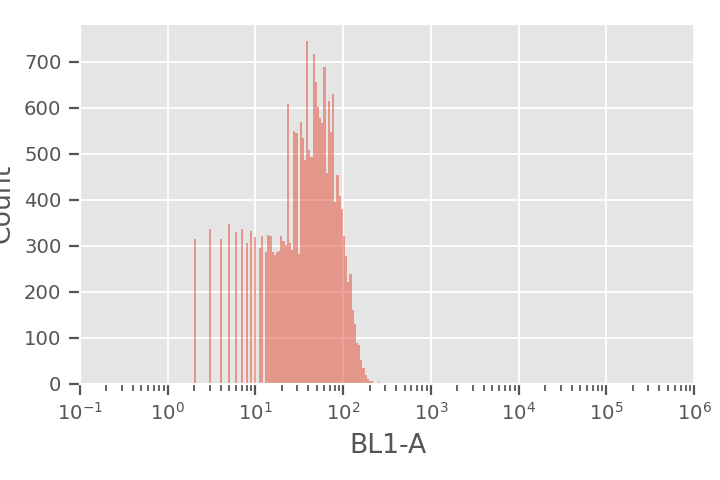

In [12]:
for chan in CHANNELS.keys():
    chan="BL1-A"
    threshold_gate = flow.ThresholdOp(
        name=chan,
        channel=chan
    )

    threshold_gate.default_view(
        huescale="log",
        interactive=True,
        subset = f"(Single_Cell == True) and (Construct == '{ALL_NEG_CONSTRUCT}')",
        scale="log"
    ).plot(ex)
    this_fig = plt.gcf()
    this_fig.canvas.draw_idle()

    GATE_INFO[f"{chan}_threshold"] = threshold_gate.threshold
    ex = threshold_gate.apply(ex)
    plt.close()
    
    



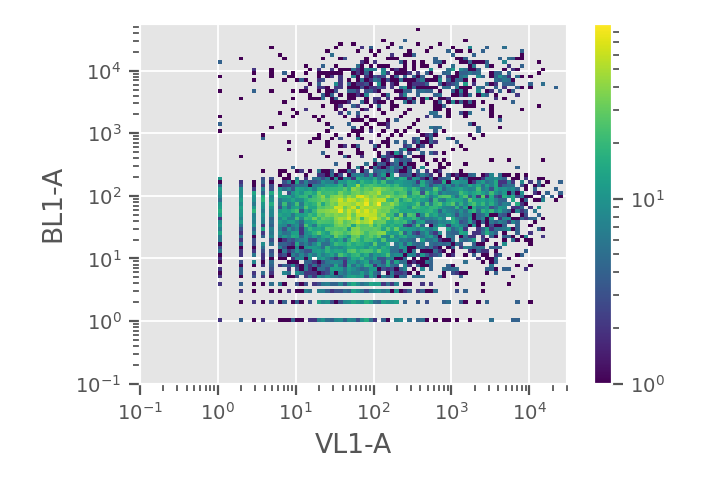

In [13]:
quad_gate = flow.QuadOp(
    name="d_pos",
    xchannel="VL1-A",
    ychannel="BL1-A",
    # xscale="logicle",
    # yscale="logicle"
)

quad_gate.default_view(
    density = True,
    huescale = "log",
    interactive = True,
    subset = "Single_Cell == True",
    xscale="log", yscale="log"
).plot(ex, gridsize=100)

In [22]:
quad_gate.xthreshold
quad_gate.ythreshold

1306.2777743918798

In [14]:
ex = quad_gate.apply(ex)
plt.close()

In [15]:
if isinstance(Experiment, NodeExperimentsDirectory):
    ex.data.to_csv(os.path.join(Experiment.output_dirpath, "processed_data.csv"))

plot_data = ex.data[ex.data["Single_Cell"]==True]

# The following lines are to prevent NANs being fed into log y axes
# They may not be necessary with newer versions of Cytoflow (>1.2.2)
num_cols = plot_data.select_dtypes(include='number').columns
plot_data[num_cols] = plot_data[num_cols].replace(0, 1)

order = ['dCas9-ZIM3', 'H3t-D3L-dCas9', 'H3t-D3L-dCas9-KOX1', 'H3t-KOX1-D3L-dCas9']
order_no_krab = ['H3t-D3L-dCas9', 'H3t-D3L-dCas9-KOX1', 'H3t-KOX1-D3L-dCas9']

channel_labels = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": "VL1-A",
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": "BL1-A",
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": "RL1-A",
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": "YL1-A"
}

channel_cmaps = {
    f"{BLUE_CHANNEL_NAME} ({BLUE_CHANNEL_TAG})": black_blue_pastel_palette,
    f"{GREEN_CHANNEL_NAME} ({GREEN_CHANNEL_TAG})": black_green_pastel_palette,
    f"{RED_CHANNEL_NAME} ({RED_CHANNEL_TAG})": black_red_pastel_palette,
    f"{YELLOW_CHANNEL_NAME} ({YELLOW_CHANNEL_TAG})": black_yellow_pastel_palette
}

FOCUS_CHANNEL_LABEL = list(channel_labels.keys())[list(channel_labels.values()).index(FOCUS_CHANNEL)]

/tmp/ipykernel_113493/192654032.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


## Graphing

In [16]:
%matplotlib inline

/data_gilbert3/asathler/miniforge3/envs/single-cell/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
/data_gilbert3/asathler/repos/ARS_Flow/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/data_gilbert3/asathler/miniforge3/envs/single-cell/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
/data_gilbert3/asathler/repos/ARS_Flow/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

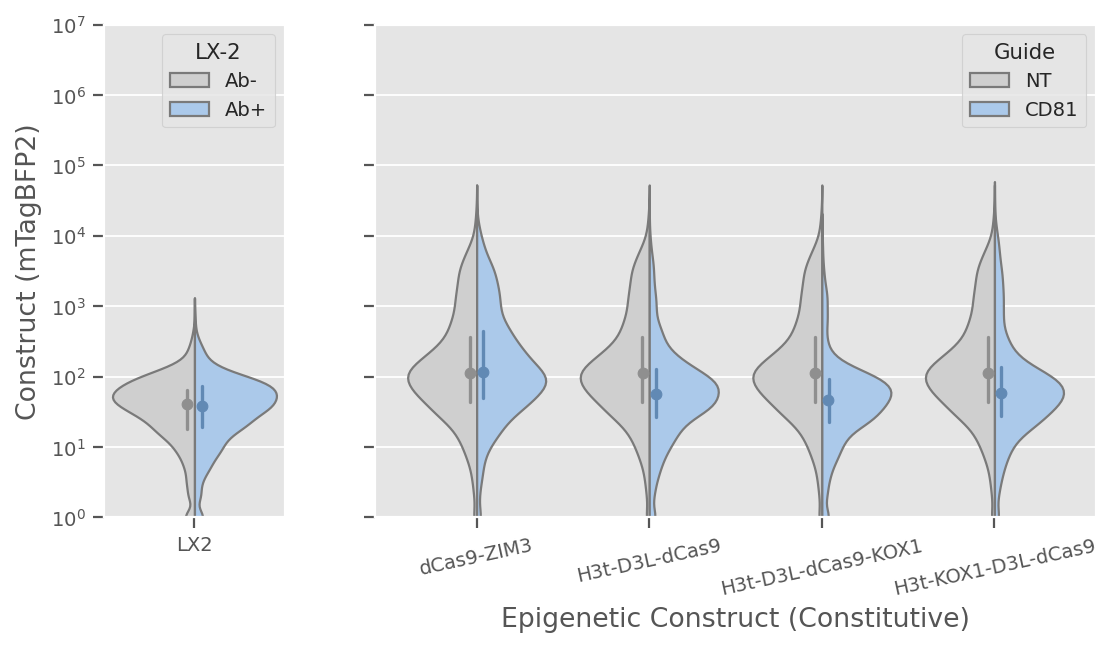

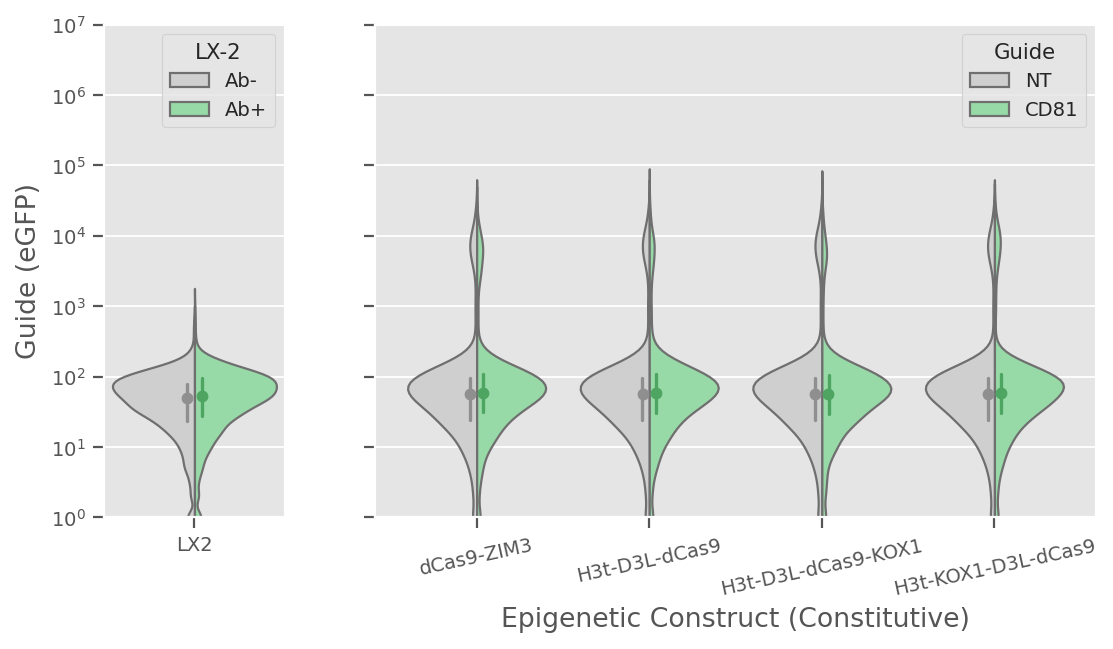

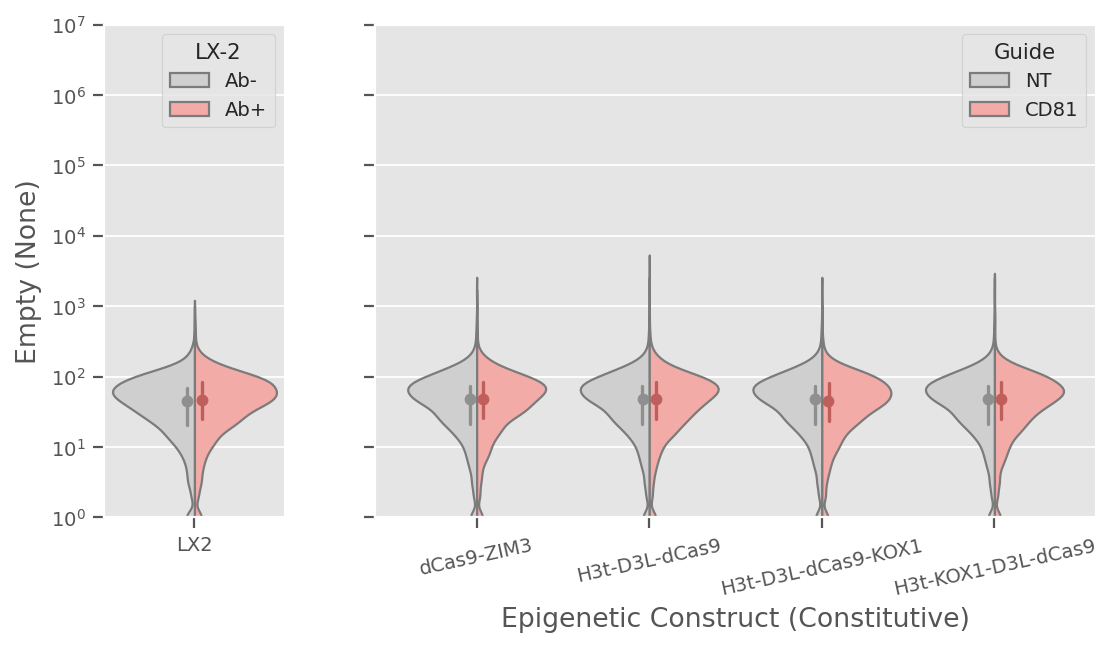

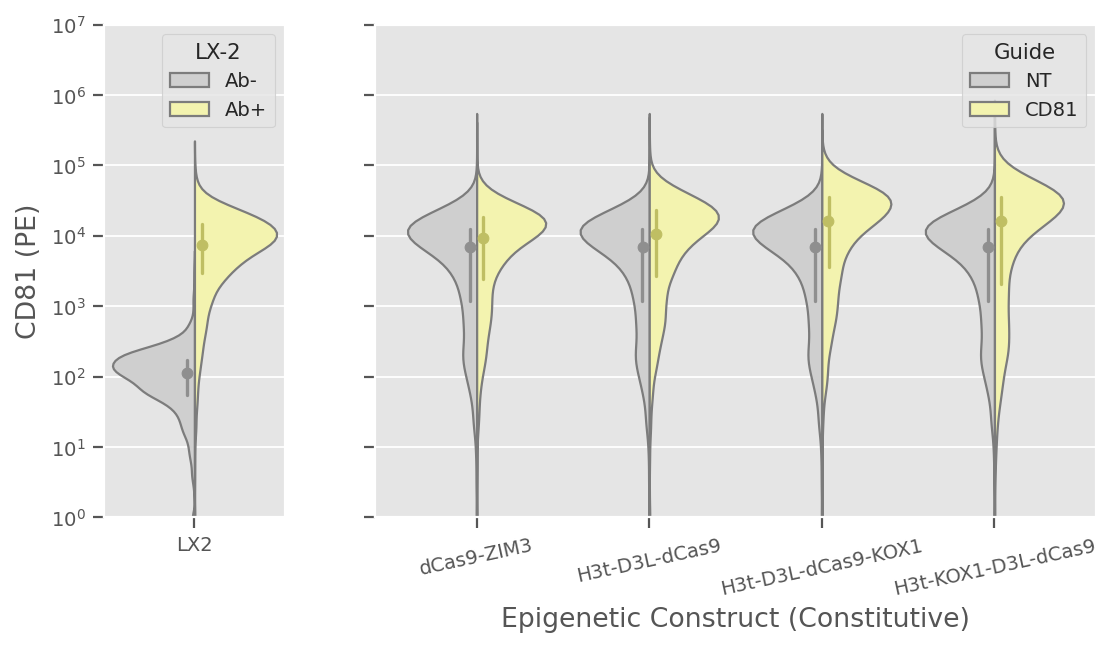

In [18]:
for fluor, flow_channel in channel_labels.items():
    # See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
    fig, axs = plt.subplot_mosaic(
        [
            ["Mock", "Construct"]
        ],
        figsize=(8,4),
        width_ratios=(1,4),
        sharey=True
        # layout="consrained"
    )

    flow_violin(
        data=plot_data.loc[(plot_data["Construct"] == "LX2")],
        x="Construct",
        y=flow_channel,
        hue="Guide",
        palette=channel_cmaps[fluor],
        split=True,
        log_y_axis=True,
        hue_order=["Ab-", "Ab+"],
        order=["LX2"],
        ylabel=fluor,
        xlabel="",
        density_norm='width',
        ylim=YLIMITS,
        ax=axs['Mock']
    )

    flow_violin(
        data=plot_data.loc[(plot_data["Construct"] != "LX2") & (plot_data["Construct"] != "Unstained")],
        x="Construct",
        y=flow_channel,
        hue="Guide",
        palette=channel_cmaps[fluor],
        order=order,
        split=True,
        log_y_axis=True,
        xlabel="Epigenetic Construct (Constitutive)",
        ylabel="",
        hue_order=["NT", "CD81"],
        legend_labels=["NT", "CD81"],
        ylim=YLIMITS,
        density_norm='width',
        ax=axs['Construct']
    )

    axs['Mock'].legend(title="LX-2", loc="upper right")
    axs['Construct'].legend(title="Guide", loc="upper right")
    axs['Construct'].set_xticklabels(axs['Construct'].get_xticklabels(), rotation=12.25)
    fig.subplots_adjust()
    if isinstance(Experiment, NodeExperimentsDirectory):
        plt.savefig(os.path.join(Experiment.output_dirpath, f"{fluor}.png"))

/data_gilbert3/asathler/miniforge3/envs/single-cell/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
/data_gilbert3/asathler/repos/ARS_Flow/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/data_gilbert3/asathler/miniforge3/envs/single-cell/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
/data_gilbert3/asathler/repos/ARS_Flow/flow_analysis_tools/_flow_violin.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

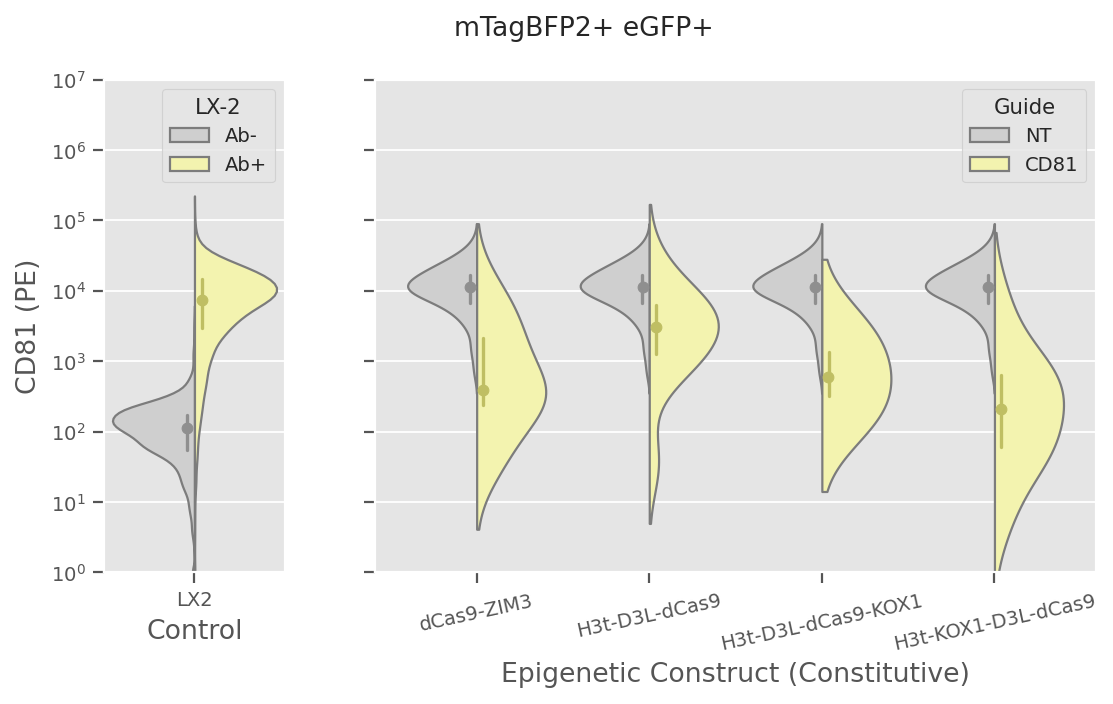

In [20]:
# See: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html#id1
fig, axs = plt.subplot_mosaic(
    [
        ["Mock", "Construct"]
    ],
    figsize=(8,4),
    width_ratios=(1,4),
    sharey=True
    # layout="consrained"
)

flow_violin(
    data=plot_data[(plot_data["Construct"] == "LX2")],
    x="Construct",
    y=FOCUS_CHANNEL,
    hue="Guide",
    palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
    # order=list(CONSTRUCT_NAMES),
    split=True,
    log_y_axis=True,
    hue_order=["Ab-", "Ab+"],
    order=["LX2"],
    ylabel=FOCUS_CHANNEL_LABEL,
    xlabel="Control",
    ylim=YLIMITS,
    ax=axs['Mock']
)

flow_violin(
    data=plot_data[(plot_data["d_pos"] == "d_pos_2") & (plot_data["Construct"] != "LX-2")],
    x="Construct",
    y=FOCUS_CHANNEL,
    hue="Guide",
    palette=channel_cmaps[FOCUS_CHANNEL_LABEL],
    order=order,
    split=True,
    log_y_axis=True,
    xlabel="Epigenetic Construct (Constitutive)",
        hue_order=["NT", "CD81"],
        legend_labels=["NT", "CD81"],
    ylim=YLIMITS,
    density_norm='width',
    ax=axs['Construct']
)
axs['Mock'].legend(title="LX-2", loc="upper right")
axs['Construct'].legend(title="Guide", loc="upper right")
axs['Construct'].set_xticklabels(axs['Construct'].get_xticklabels(), rotation=12.25)
fig.suptitle(f"{BLUE_CHANNEL_TAG}+ {GREEN_CHANNEL_TAG}+")
if isinstance(Experiment, NodeExperimentsDirectory):
    plt.savefig(os.path.join(Experiment.output_dirpath, f"{FOCUS_CHANNEL}_construct_and_guide_only.png"))

In [24]:
Experiment.close()